# Pricing Models Comparison - European Options

This notebook prices one European call and one European put across all three engines (Black-Scholes-Merton, Binomial Tree, Monte Carlo) and displays the results in a table. Then it shows convergence: it plots how the prices obtained from the Binomial Tree engine approach the Black-Scholes-Merton (BSM) price as `num_tree_steps` increases, and how Monte Carlo approaches BSM as `num_paths` increases. This visually demonstrates that the Binomial Tree and Monte Carlo prices converge to the BSM price.

## Import Python Libraries

In [1]:
import sys
sys.path.append('..') # add the project root directory

In [9]:
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt

## Import Necessary Objects from My Option Pricing Library

In [2]:
from instruments.european import EuropeanOption

from core.enums import OptionType

from market.environment import MarketEnvironment

from engines.black_scholes_merton import BlackScholesMertonPricer
from engines.binomial_tree import BinomialTreePricer
from engines.monte_carlo import MonteCarloPricer

## Instantiate the Option and Market Environment

In [4]:
market = MarketEnvironment(spot_price = 100, risk_free_rate = 0.10, volatility = 0.4, dividend_yield = 0.05, pricing_date = date(2026, 3, 18))
eu_call = EuropeanOption(strike_price = 100, expiry_date = date(2026, 9, 18), option_type = OptionType.CALL)
eu_put = EuropeanOption(strike_price = 100, expiry_date = date(2026, 9, 18), option_type = OptionType.PUT)

## Pricing the Same Option across the Three Engines

In [36]:
num_tree_steps = 100 # choose the number of time steps in the Binomial Tree
num_paths_mc = 100000 # choose the number of paths for Monte Carlo
seed = 42 # set random seed for reproducibility

# Price the European call option using the three engines
price_bsm_call = eu_call.price(pricer = BlackScholesMertonPricer(), market_env = market)
price_tree_call = eu_call.price(pricer = BinomialTreePricer(num_tree_steps = num_tree_steps), market_env = market)
price_mc_call = eu_call.price(pricer = MonteCarloPricer(num_paths = num_paths_mc, random_seed = seed), market_env = market)

# Price the European put option using the three engines
price_bsm_put = eu_put.price(pricer = BlackScholesMertonPricer(), market_env = market)
price_tree_put = eu_put.price(pricer = BinomialTreePricer(num_tree_steps = num_tree_steps), market_env = market)
price_mc_put = eu_put.price(pricer = MonteCarloPricer(num_paths = num_paths_mc, random_seed = seed), market_env = market)

In [6]:
pd.DataFrame(
    {
        'Price CALL': [price_bsm_call, price_tree_call, price_mc_call],
        'Difference from BSM': [price_bsm_call-price_bsm_call, price_tree_call-price_bsm_call, price_mc_call-price_bsm_call]
    },
    index=['BSM', 'Tree', 'MC']
)

,Price CALL,Difference from BSM
BSM,12.130060,0.000000
Tree,12.102807,-0.027253
MC,12.109073,-0.020987


In [8]:
pd.DataFrame(
    {
        'Price PUT': [price_bsm_put, price_tree_put, price_mc_put],
        'Difference from BSM': [price_bsm_put-price_bsm_put, price_tree_put-price_bsm_put, price_mc_put-price_bsm_put]
    },
    index=['BSM', 'Tree', 'MC']
)

,Price PUT,Difference from BSM
BSM,9.702966,0.000000
Tree,9.675714,-0.027253
MC,9.766798,0.063832


## Model Validation and Comparative Analysis
The tables above compare the results of the three pricing engines for At-The-Money (ATM) European options. With the market parameters set ($S=K=100$, $\sigma=40\%$, $r=10\%$, $q=5\%$), we can draw several key conclusions about the library's performance and the behavior of numerical models.

#### 1. Binomial Tree Performance ($N=100$)
*   **Consistency:** The Binomial Tree exhibits a highly consistent error of approximately **-0.027** for both the Call and the Put. This identical "Difference from BSM" is expected for ATM options when using the Cox-Ross-Rubinstein (CRR) parameterization, as the discretization error affects the terminal distribution symmetrically.
*   **Precision:** By choosing $N=100$ (an even number), we have eliminated the "straddle" error (the overestimation caused by missing the strike price kink). The remaining small difference is the standard discretization error that would continue to shrink if we increased $N$ further.

#### 2. Monte Carlo Performance ($N=100,000$)
*   **Statistical Noise:** Unlike the tree, the Monte Carlo errors are not identical for the Call (-0.021) and the Put (+0.064). This variation is a result of **sampling error**. Even with 100,000 paths, the random nature of the simulation means the sample mean will fluctuate slightly around the true theoretical mean.
*   **Accuracy:** Both results are within a very narrow margin of the BSM price (less than 1% relative error). This confirms that the `MonteCarloPricer` is correctly sampling from the log-normal distribution and that 100,000 paths provide a high level of confidence for European-style payoffs.


The results demonstrate that the library is internally consistent. The analytical **Black-Scholes-Merton** pricer provides the "exact" solution, while both the **Binomial Tree** (a discrete lattice approach) and **Monte Carlo** (a stochastic sampling approach) converge toward that benchmark. 

The close alignment between the numerical differences (all within roughly 2–6 cents of the benchmark) validates that the pricing engines are correctly implemented and that the chosen hyper-parameters (`num_tree_steps` steps and `num_paths_mc` paths) are sufficient for reliable valuation.

---

## Binomial Tree Convergence

This section examines how the discrete Binomial Tree model converges to the continuous Black-Scholes-Merton (BSM) analytical price. 

To visualize this process, we will price standard European Call and Put options using our `BinomialTreePricer` across a dense, sequential range of time steps, specifically, calculating the price for every step count from 5 up to 100 (`steps = list(range(5, 101))`). 

By plotting these calculated tree prices against the exact BSM benchmark, we can observe the model's convergence behavior in real-time. As we will see in the resulting charts, the discrete tree does not approach the BSM price in a simple, smooth curve, but rather exhibits a highly distinct structural pattern. Following the visualizations, we will provide a detailed mathematical breakdown of exactly what convergence means, why the Central Limit Theorem guarantees it, and what geometric mechanics drive its unique oscillatory shape.

### Call Option

In [14]:
steps = list(range(5, 101))
prices_tree_call = [eu_call.price(pricer = BinomialTreePricer(num_tree_steps = n), market_env = market) for n in steps]

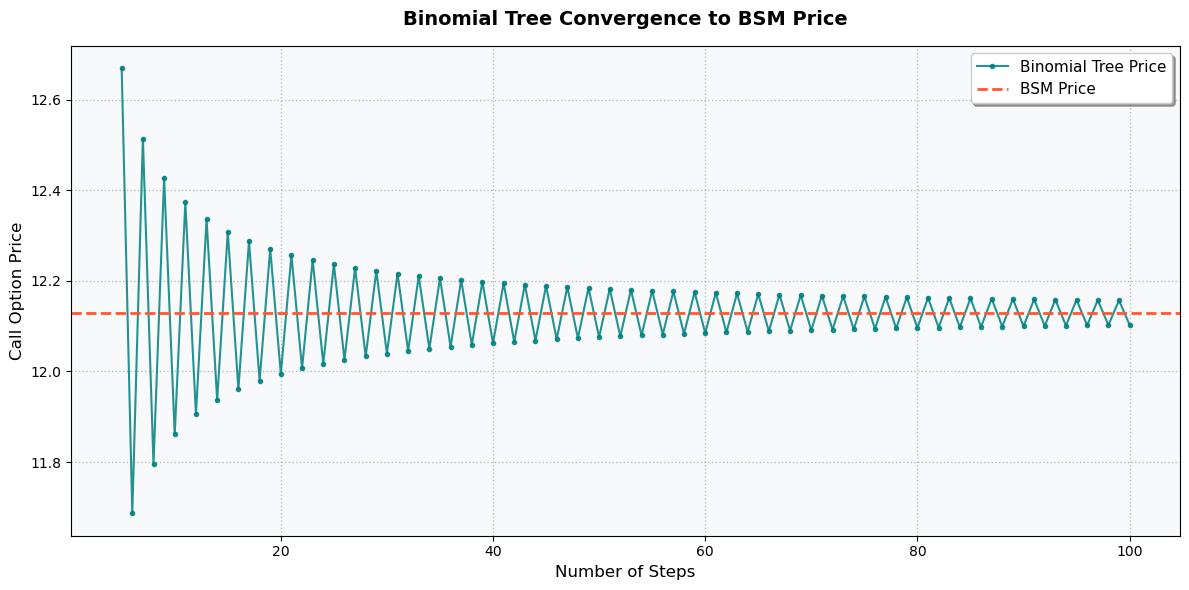

In [31]:
plt.figure(figsize=(12, 6))

plt.gca().set_facecolor('#f8f9fa')

plt.plot(steps, prices_tree_call, marker='o', markersize=3, 
         linestyle='-', linewidth=1.5, color='#008080', 
         alpha=0.85, label='Binomial Tree Price')

# Add the horizontal dashed line for the Black-Scholes-Merton price
plt.axhline(y=price_bsm_call, color='#FF5733', linestyle='--', 
            linewidth=2, label='BSM Price')

plt.title('Binomial Tree Convergence to BSM Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Steps', fontsize=12)
plt.ylabel('Call Option Price', fontsize=12)

plt.legend(fontsize=11, frameon=True, shadow=True, facecolor='white')

plt.grid(True, linestyle=':', linewidth=1, color='gray', alpha=0.5)

plt.tight_layout()

plt.show()

### Put Option

In [17]:
steps = list(range(5, 101))
prices_tree_put = [eu_put.price(pricer = BinomialTreePricer(num_tree_steps = n), market_env = market) for n in steps]

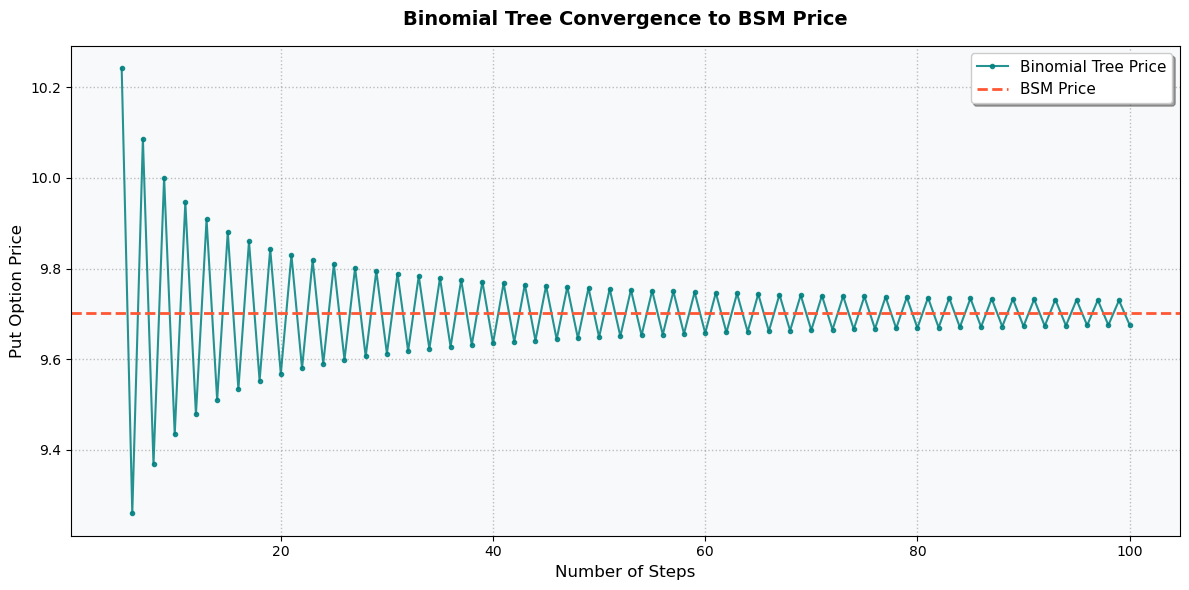

In [34]:
plt.figure(figsize=(12, 6))

plt.gca().set_facecolor('#f8f9fa')

plt.plot(steps, prices_tree_put, marker='o', markersize=3, 
         linestyle='-', linewidth=1.5, color='#008080', 
         alpha=0.85, label='Binomial Tree Price')

# Add the horizontal dashed line for the Black-Scholes-Merton price
plt.axhline(y=price_bsm_put, color='#FF5733', linestyle='--', 
            linewidth=2, label='BSM Price')

plt.title('Binomial Tree Convergence to BSM Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Steps', fontsize=12)
plt.ylabel('Put Option Price', fontsize=12)

plt.legend(fontsize=11, frameon=True, shadow=True, facecolor='white')

plt.grid(True, linestyle=':', linewidth=1, color='gray', alpha=0.5)

plt.tight_layout()

plt.show()

### Binomial Tree Convergence to BSM

Convergence here refers to the property of the discrete Binomial Tree pricing model approaching the continuous Black-Scholes-Merton (BSM) analytical price as the number of time steps ($N$) - `num_tree_steps` in the code - approaches infinity. 

Showing convergence matters for two primary reasons. First, it validates the numerical model; if the tree did not converge to the exact BSM solution for European options, it would be fundamentally flawed. Second, because in practice we use binomial trees to price options that *do not* have closed-form solutions (like American options also priced in this project), analyzing this convergence behavior tells us how many steps we need to choose to achieve a reliable price, balancing computational cost against mathematical accuracy.

The Cox-Ross-Rubinstein (CRR) parameterization is specifically designed so that the discrete model's volatility and expected return match the continuous BSM model over the same time horizon. However, a fundamental characteristic and limitation of the binomial tree is that the number of time steps dictates the price granularity. 

An $N$-step tree yields exactly $N+1$ possible terminal asset prices. Therefore, to sample more points along the option's payoff line and improve accuracy, we are forced to increase the number of steps. The more densely we sample the terminal payoffs, the better our discrete approximation becomes.

The Binomial Tree converges to the BSM price because of the **Central Limit Theorem**. 
The BSM model assumes that the underlying asset price follows a continuous random walk called Geometric Brownian Motion (GBM), resulting in a log-normal distribution of terminal prices. The binomial tree, on the other hand, is a discrete random walk driven by multiplicative percentage changes. As we increase the number of steps ($N$), the time interval ($\Delta t$) for each step becomes infinitesimally small. By the Central Limit Theorem, the sum of these discrete, logarithmic returns converges to a Normal distribution. Consequently, the distribution of the **discrete terminal asset prices** smoothly transitions into the exact continuous **log-normal distribution** of the BSM model. Because the statistical distributions of the terminal prices perfectly align in the limit, the discounted expected payoffs (the option prices) must also align.

As seen in the charts above, the convergence is not a smooth line; it oscillates rapidly around the BSM benchmark. This classic "sawtooth" behavior is caused by the **non-linearity of the option payoff function** and how the tree's terminal nodes align with the strike price.

* **The Payoff Kink:** An option's payoff has a sharp "kink" exactly at the strike price $K$ (e.g., $\max(S_T - K, 0)$). The continuous BSM formula integrates smoothly over this kink. 
* **Node Shifting:** The binomial tree evaluates the payoff only at discrete nodes. As you change the number of steps from $N$ to $N+1$, the exact numerical values of all the terminal nodes shift slightly.
* **Odd vs. Even Steps:** Depending on the number of steps, the final nodes will align differently relative to the strike price. For example, if the initial stock price equals the strike price (At-The-Money) as in our example here, a tree with an *even* number of steps will always place a terminal node exactly on the strike price. A tree with an *odd* number of steps will have nodes that straddle the strike price, but none exactly on it. 

This constant shifting of terminal nodes jumping back and forth across the "kink" in the payoff function causes the discrete approximation to systematically alternate between overestimating and underestimating the true continuous price, resulting in the oscillatory pattern.

---

## Monte Carlo Convergence

In this section, we transition from the discrete, lattice-based approach of the Binomial Tree to a simulation-based pricing method: the Monte Carlo approach. 

Unlike the systematic "sawtooth" steps of a tree, Monte Carlo pricing generates a finite number of random price paths to estimate the expected payoff. To evaluate its accuracy, we systematically increase the number of simulated paths across several orders of magnitude - from as few as 100 to as many as 500,000. We also utilize a fixed `random_seed` (set in the beginning of this notebook) to ensure our results are reproducible and that the convergence behavior we observe is a true reflection of the sample size rather than random variation between experiments.

By plotting these results on a **logarithmic scale**, we can clearly visualize how the initial "statistical noise" in the simulation begins to settle. Following the charts, we provide a detailed explanation of the **Fundamental Asset Pricing Formula** and the statistical laws that govern why and how fast this simulation converges to the Black-Scholes-Merton benchmark.

### Call Option

In [23]:
paths = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000]
prices_mc_call = [eu_call.price(pricer = MonteCarloPricer(num_paths = n, random_seed = seed), market_env = market) for n in paths]

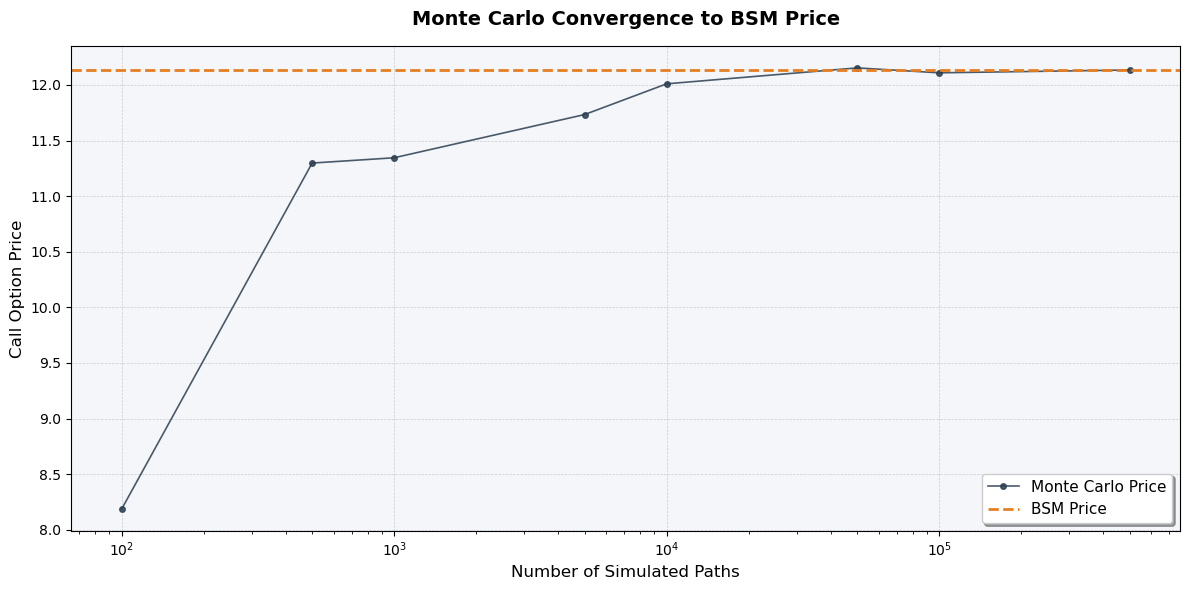

In [32]:
plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#f4f6f9')

plt.plot(paths, prices_mc_call, marker='o', markersize=4, 
         linestyle='-', linewidth=1.2, color='#2C3E50', 
         alpha=0.85, label='Monte Carlo Price')

# BSM call price - horizontal line
plt.axhline(y=price_bsm_call, color='#E67E22', linestyle='--', 
            linewidth=2, label='BSM Price')

plt.xscale('log')

plt.title('Monte Carlo Convergence to BSM Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Simulated Paths', fontsize=12)
plt.ylabel('Call Option Price', fontsize=12)

plt.legend(fontsize=11, frameon=True, shadow=True, facecolor='white')
plt.grid(True, linestyle='--', linewidth=0.5, color='#bdc3c7', alpha=0.8)

plt.tight_layout()
plt.show()

### Put Option

In [27]:
paths = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000]
prices_mc_put = [eu_put.price(pricer = MonteCarloPricer(num_paths = n, random_seed = seed), market_env = market) for n in paths]

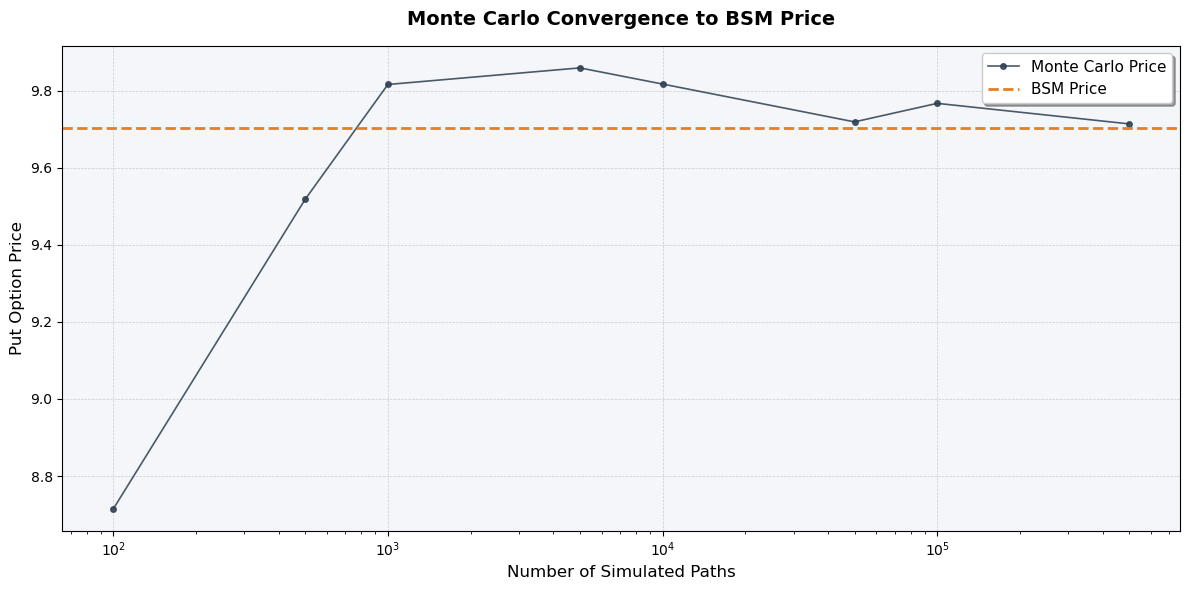

In [33]:
plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#f4f6f9')

plt.plot(paths, prices_mc_put, marker='o', markersize=4, 
         linestyle='-', linewidth=1.2, color='#2C3E50', 
         alpha=0.85, label='Monte Carlo Price')

# BSM put price - horizontal line
plt.axhline(y=price_bsm_put, color='#E67E22', linestyle='--', 
            linewidth=2, label='BSM Price')

plt.xscale('log')

plt.title('Monte Carlo Convergence to BSM Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Simulated Paths', fontsize=12)
plt.ylabel('Put Option Price', fontsize=12)

plt.legend(fontsize=11, frameon=True, shadow=True, facecolor='white')
plt.grid(True, linestyle='--', linewidth=0.5, color='#bdc3c7', alpha=0.8)

plt.tight_layout()
plt.show()

### Monte Carlo Convergence to BSM
In the context of Monte Carlo simulation, convergence refers to the property where the sample average of our simulated option payoffs approaches the true, theoretical expected value (the BSM price) as the number of simulated price paths ($N$) approaches infinity. 

Understanding this convergence is critical for two main reasons. First, it **validates our simulation engine**. By testing our Monte Carlo pricer on standard European calls and puts - where we already know the exact BSM answer - we can prove our random number generation and payoff logic are mathematically sound. Second, it dictates our **computational budget**. In practice, we use Monte Carlo to price highly complex, path-dependent options (like Asian options also priced in this project) where no analytical BSM formula exists. Analyzing this convergence profile tells us how many paths we need to run to achieve an acceptable margin of error without wasting computational power.

Monte Carlo convergence relies on a direct application of the **Fundamental Asset Pricing Formula**, driven by two core statistical theorems: the Law of Large Numbers (LLN) and the Central Limit Theorem (CLT).

The fundamental asset pricing formula states that the fair price of any derivative is the **expected value of its discounted future payoff** under a risk-neutral probability measure: $\text{Price} = \mathbb{E}^\mathbb{Q}[e^{-rT} \cdot \text{Payoff}]$. 

A Monte Carlo pricer approaches this expectation through randomized empirical sampling. It generates thousands of simulated terminal stock prices directly from a continuous log-normal distribution, calculates the discounted payoff for each, and takes the sample average. 

*   **The Destination:** The **Law of Large Numbers (LLN)** mathematically guarantees that as the sample size ($N$) approaches infinity, this simulated sample average will perfectly converge to the true theoretical expected value defined by the fundamental pricing formula (the BSM price).
*   **The Journey:** The **Central Limit Theorem (CLT)** dictates the distribution of the error around that true price. Because the sample average is composed of independent, identically distributed simulated payoffs, the CLT guarantees that the standard error of the simulation scales exactly by $\frac{\sigma}{\sqrt{N}}$.

The x-axis on these charts uses a logarithmic scale (e.g., $10^2, 10^3, 10^4$). This beautifully illustrates the harsh reality of the CLT's $1/\sqrt{N}$ rule. Because the error shrinks at the rate of the square root of $N$, cutting the pricing error in half requires running **4 times** as many paths. Increasing the precision by one decimal place requires **100 times** as many paths. The logarithmic scale clearly shows this computational burden, as the massive leaps in path count yield smaller and smaller refinements as the price tightly hugs the BSM benchmark.

---

## Conclusion

All three pricing engines converge to the same theoretical option price, validating the correctness of each implementation.

**Black-Scholes-Merton** provides the "exact" analytical price instantaneously — it is the benchmark against which we test the numerical methods.

**Binomial Tree (CRR)** converges deterministically with increasing time steps, exhibiting the characteristic oscillatory pattern caused by discrete node placement relative to the strike price. With 100 steps, the tree price is already within a few cents of BSM.

**Monte Carlo** converges stochastically with increasing simulated paths, with the standard error shrinking at the rate of $1/\sqrt{N}$. With 100,000 paths, the Monte Carlo price closely matches BSM, though each run with a different random seed will produce a slightly different result.

The key tradeoff: BSM is exact but limited to European options with constant parameters. Binomial Trees extend naturally to American options with early exercise. Monte Carlo extends to path-dependent exotics like Asian options. The convergence demonstrated here gives us confidence in the numerical engines when we apply them to problems where no closed-form solution exists.